# <center>基于反向随机微分方程的扩散模型</center>

## 1. 问题描述

考虑方差保持型（Variance Preserving）的正向随机微分方程
$$
\mathbf{X} (0) \sim p_{\text{data}}(x), \ \ \ \
d \mathbf{X} (t) = - \frac12 \beta(t) \mathbf{X} (t) dt + \sqrt{\beta(t)} d\mathbf{W} (t)
\ \ \
\textnormal{其中}
\ \ \
0 < t\leq 1,
$$
其中 $\mathbf{X} (0) = (X_0(0), X_1(0))$ 为二维数据点且服从瑞士卷分布（Swiss Roll Distribution），$\mathbf{W} (t)$ 为标准的布朗运动，扩散率 
$$
\beta(t) = 0.1 + (20 - 0.1) t
$$ 
使得其概率密度函数 $p(x,t)$ 在 $t=1$ 时刻近似满足 $p(x,1)\approx \mathcal{N}( 0, I )$。对于状态变量 $\mathbf{Y} (s) = \mathbf{X} (1-s)$，通过计算其所满足的反向随机微分方程
$$
\mathbf{Y} (1) \sim p_{\text{noise}}(x) \approx \mathcal{N}( 0, I ), \ \ \ \
d \mathbf{Y} (t) = \left[ - \frac12 \beta(t) \mathbf{Y}(t) - \beta(t)\nabla \log\, {p(\mathbf{Y}(t),t) }\right] dt + \sqrt{\beta(t)} d\mathbf{W} (t)
\ \ \
\textnormal{其中}
\ \ \
0 \leq t < 1,
$$
从服从噪音分布的样本 $\mathbf{Y} (1) \sim p_{\text{noise}}(x)$ 演化生成服从数据分布的样本 $\mathbf{Y} (0) \sim p_{\text{data}}(x)$.


#### 1-1. 去噪分数匹配（Denosing Score Matching）

首先通过神经网络来逼近分数函数

$$
s_{\textnormal{NN}}( \mathbf{X}, t; \theta ) \approx \nabla \log\, {p(\mathbf{X},t) }
$$
其中 $\theta$ 表示模型的可训练参数，接着利用 Bayes 公式与上述随机微分方程的转移核函数得到其对应的优化问题
$$
\underset{\theta}{\operatorname{arg\min}} 
\mathbb{E}_{t\in \mathcal{U}[0,1]} \left[ \lambda (t) \mathbb{E}_{\mathbf{X}(0)}\mathbb{E}_{\mathbf{X}(t)|\mathbf{X}(0)}\left[\left\lVert s_{\textnormal{NN}}(\mathbf{X}(t), t; \theta) - \frac{\boldsymbol{\mu}(t) - \mathbf{X}(t)}{\sigma^2(t)} \right\rVert^2\right] \right]
$$
其中权重函数 $\lambda(t) = 1 - \mathrm{exp}\left[-\int_0^t \beta(s) ds\right]$，均值为 $\displaystyle \boldsymbol{\mu}(t) = \mathbf{X}(0) \, \mathrm{exp}\left[ -\frac{1}{2}\int_0^t \beta(s) ds \right]$，方差为 $\displaystyle \sigma^2(t) = 1 - \mathrm{exp}\left[ -\int_0^t \beta(s) ds\right]$，且可根据后验分布
$$
p( \mathbf{X}(t) \,|\, \mathbf{X}(0) ) = \mathcal{N}( \boldsymbol{\mu}(t), \sigma^2(t) I ),
$$
来直接生成从 $\mathbf{X}(0)$ 出发的状态变量 $\mathbf{X}(t)$。

#### 1-2. 反向生成模型（Reverse Generative Model）

将训练所得分数函数模型带入反向随机微分方程
$$
\mathbf{Y} (1) \sim p_{\text{noise}}(x) \approx \mathcal{N}( 0, I ), \ \ \ \
d \mathbf{Y} (t) = \left[ - \frac12 \beta(t) \mathbf{Y}(t) - \beta(t)\nabla s_{\textnormal{NN}}( \mathbf{X}, t; \theta^* ) \right] dt + \sqrt{\beta(t)} d\mathbf{W} (t)
\ \ \
\textnormal{其中}
\ \ \
0 \leq t < 1,
$$
并通过数值离散进行求解，将服从噪音分布的样本 $\mathbf{Y} (1) \sim p_{\text{noise}}(x)$ 演化生成服从数据分布的样本 $\mathbf{Y} (0) \sim p_{\text{data}}(x)$.

在数值模拟时，需要对反向随机微分方程进行离散后进行计算。将时间进行网格剖分 $0=t_0 < t_1 < \cdots < t_N=1$，Euler-Maruyama 方法的数值格式为
$$
\mathbf{Y}_N = \mathbf{Y}(1), \ \ \ \
\mathbf{Y}_{n-1} = \mathbf{Y}_{n} + \left[ - \frac12 \beta(t_n) \mathbf{Y}_{n} - \beta(t_n) s_{\textnormal{NN}}( \mathbf{Y}_{n}, t_n; \theta^* ) \right] \Delta t_n + \sqrt{\beta(t_n)} \Delta \mathbf{W}_n
\ \ \
\textnormal{其中}
\ \ \
n=1,\cdots,N,
$$
其中 $\Delta \mathbf{W}_n \sim \mathcal{N}(0,\Delta t_n)$，$\Delta t_n=t_{n}-t_{n-1}$。

## 2. 编程求解（瑞士卷数据集）

In [6]:
import torch
import torch.nn as nn
import numpy as np
import time
import datetime

from torch.utils.data import DataLoader
from sklearn.datasets import make_swiss_roll

import matplotlib.pyplot as plt

### 2-1. 正向过程的初值样本生成

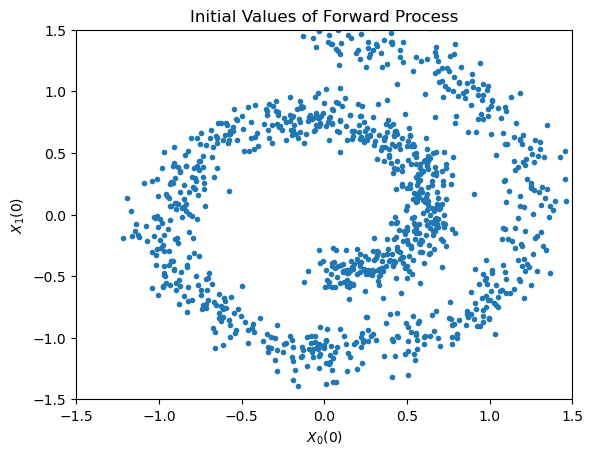

In [50]:
# load Swiss Roll dataset as initial value of forward process
datasize_train = 1000
batchsize_train = 200

x_3D, _ = make_swiss_roll(datasize_train, noise=1.0)
x_2D = torch.as_tensor(x_3D[:, [0, 2]] / 10.0, dtype=torch.float32) # project to 2D plane and scale to [-1, 1]

dataset_train = torch.utils.data.TensorDataset(x_2D)
dataloader_train = DataLoader(dataset_train, batch_size=batchsize_train, shuffle=True)

# display sample points
plt.plot(x_2D[:, 0], x_2D[:, 1], 'C0.')
plt.title('Initial Values of Forward Process')
plt.xlabel('$X_0(0)$')
plt.ylabel('$X_1(0)$')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
axes[idx].set_aspect('equal')
plt.show()

### 2-2. 分数函数的神经网络逼近

In [3]:
# define neural network for approximating score function (input dimension 2 + 1, output dimension 2)

score_network = torch.nn.Sequential(
    torch.nn.Linear(3, 64),
    torch.nn.LogSigmoid(),
    torch.nn.Linear(64, 64),
    torch.nn.LogSigmoid(),
    torch.nn.Linear(64, 64),
    torch.nn.LogSigmoid(),
    torch.nn.Linear(64, 2),
)

### 2-3. 神经网络的损失函数构建

In [4]:
def train_loss(score_network, x0):

    # time slices from uniform distribution over [1e-4, 1 - 1e-4]
    t = torch.rand((x0.shape[0], 1), dtype=x0.dtype, device=x0.device) * (1 - 1e-4) + 1e-4      

    # compute score function through the posterior log distribution    
    int_beta = (0.1 + 0.5 * (20 - 0.1) * t) * t  # analytic integral of beta(s) over [0,t]
    mu_t = x0 * torch.exp( -0.5 * int_beta )
    var_t = - torch.expm1( -int_beta ) # for stability    
    x_t = torch.randn_like(x0) * var_t ** 0.5 + mu_t # compute directly from distribution
    grad_log_p = ( mu_t - x_t ) / var_t  
    
    # compute score function through the neural network prediction
    xt = torch.cat((x_t, t), dim=-1) 
    score = score_network(xt) 

    # calculate the loss function
    loss = (score - grad_log_p) ** 2
    lmbda_t = var_t
    weighted_loss = lmbda_t * loss
    
    return torch.mean(weighted_loss)

### 2-4. 分数神经网络的训练过程

In [7]:
# train mode
optmizer = torch.optim.Adam(score_network.parameters(), lr=3e-4)

since = time.time()
for epoch in range(150000):
    
    for x0, in dataloader_train:
        optmizer.zero_grad()

        # training step        
        loss = train_loss(score_network, x0)
        loss.backward()
        optmizer.step()

time_elapsed = time.time() - since
print('Done in {}'.format(str(datetime.timedelta(seconds=time_elapsed))), '!')

Done in 0:08:57.551711 !


### 2-5. 反向过程的初值样本生成

In [27]:
# Euler-Maruyama scheme for backward stochastic differential equation
def generate_samples(score_network, y_t, t_end):
    
    time_grids = torch.linspace(1, t_end, 1000)  
    beta = lambda t: 0.1 + (20 - 0.1) * t
    for i in range(len(time_grids) - 1):
        t = time_grids[i]
        dt = time_grids[i + 1] - t

        # drift and diffusion terms
        fyt = -0.5 * beta(t) * y_t
        gt = beta(t) ** 0.5
        score = score_network(torch.cat((y_t, t.expand(y_t.shape[0], 1)), dim=-1)).detach()
        drift = fyt - gt * gt * score
        diffusion = gt

        # Euler-Maruyama step
        y_t = y_t + drift * dt + diffusion * torch.randn_like(y_t) * torch.abs(dt) ** 0.5

    return y_t

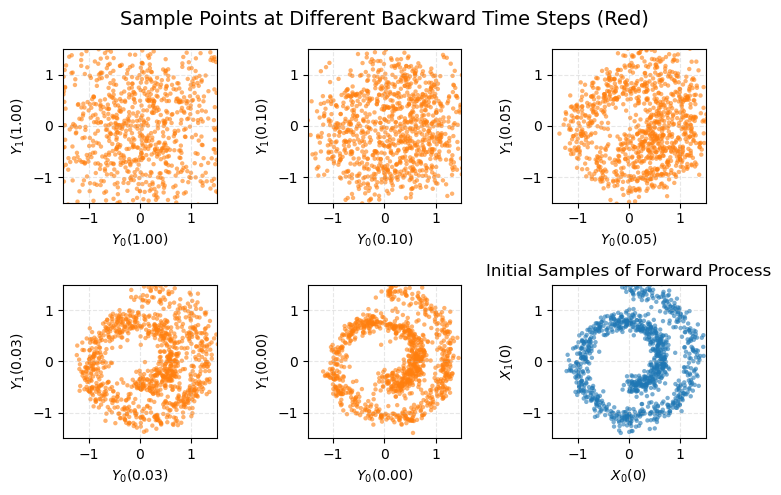

In [59]:
y_t = torch.randn((1000, 2)) # initial values for backward process
t_end = [1, 0.1, 0.05, 0.025, 0] # selected time slices for backward process

fig, axes = plt.subplots(2, 3, figsize=(15, 5))
axes = axes.flatten()
        
for idx, t in enumerate(t_end):    
    # generate samples
    samples = generate_samples(score_network, y_t, t).detach()
    # plot sample distribution
    axes[idx].scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.6, c='C1', edgecolors='none')
    axes[idx].set_xlim(-1.5, 1.5)
    axes[idx].set_ylim(-1.5, 1.5)
    axes[idx].set_aspect('equal')
    axes[idx].grid(True, linestyle='--', alpha=0.3)
    axes[idx].set_xlabel(f"$Y_0({t:.2f})$")
    axes[idx].set_ylabel(f"$Y_1({t:.2f})$")

# initial samples of forward process
axes[5].scatter(x_2D[:, 0], x_2D[:, 1], s=10, alpha=0.6, c='C0', edgecolors='none')
axes[5].set_title('Initial Samples of Forward Process', fontsize=12)
axes[5].set_xlim(-1.5, 1.5)
axes[5].set_ylim(-1.5, 1.5)
axes[5].set_aspect('equal')
axes[5].grid(True, linestyle='--', alpha=0.3)
axes[5].set_xlabel('$X_0(0)$')
axes[5].set_ylabel('$X_1(0)$')

plt.suptitle("Sample Points at Different Backward Time Steps (Red)", fontsize=14)
plt.subplots_adjust(wspace=-0.9, hspace=0.35)
plt.tight_layout()
plt.show()

## 3. 课后练习（Talk is cheap. Show me the code.）

### 练习题目 1
- 采用 Milstein 等更高阶的数值离散格式（或自适应步长）求解反向随机微分方程，并应用于图像生成等更复杂的案例。

### 练习题目 2
- 正向随机微分方程所对应的概率密度函数也可以用一个常微分方程（Probability Flow）表达，比较其与反向随机微分方程的训练稳定性与收敛速度。
  
### 练习题目 3
- 研究如何学习从噪声到数据的最优传输映射（Optimal Transport），使得生成路径最短、计算量最小。

### 练习题目 4
- 对于分子生成、社交网络等非欧几里得空间上的数据，研究在图结构上随机微分方程的定义，并编程实现扩散模型。

### 练习题目 5
- 在用数据驱动的方式学习分数函数以外，通过物理信息机器学习（Physics-Informed Machine Learning）将概率密度函数满足 Fokker-Planck 方程做为额外的损失函数，从而提升分数函数的训练质量。
